# 🚗 AI/ML-Based Automotive Intrusion Detection System

## Project Overview

Modern vehicles rely on a **Controller Area Network (CAN Bus)** for inter-ECU communication.  
The CAN protocol was designed for reliability — **not security**. It has:
- **No encryption** of message payloads
- **No authentication** of sender ECUs
- **Broadcast-only** communication (every ECU sees every message)

This makes vehicles vulnerable to cyberattacks such as **Denial-of-Service (DoS)**, **message spoofing**, and **replay attacks**.

### Objective
Build a multi-layer intrusion detection system that:
1. Detects malicious CAN Bus messages using supervised & unsupervised ML
2. Monitors vehicle telematics for anomalous driving behavior
3. Fuses both layers into a unified risk-assessment system

---
**Libraries:** pandas · numpy · matplotlib · seaborn · scikit-learn

In [1]:
# ============================================================
# Section 0 — Setup & Imports
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

# --- Global Configuration ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot aesthetics
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "axes.titleweight": "bold",
})

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
# 1 · Data Loading

## CAN Bus Message Format

| Field | Description |
|-------|-------------|
| `timestamp` | Time the message was observed (seconds, UNIX epoch) |
| `can_id` | Arbitration ID — identifies the ECU / function (hex) |
| `dlc` | Data Length Code (0–8 bytes) |
| `data[0]`–`data[7]` | Payload bytes (hex) |
| `label` | Ground truth — Normal or Attack type |

### Dataset: HCRL Car-Hacking Dataset

This notebook uses the **Car-Hacking Dataset** from the Hacking and Countermeasure Research Lab (HCRL) at Korea University — real CAN Bus traffic captured from a physical vehicle.

| File | Content | Flag |
|------|---------|------|
| `DoS_dataset.csv` | Normal + DoS attack messages | R=Normal, T=DoS |
| `Fuzzy_dataset.csv` | Normal + Fuzzy attack messages | R=Normal, T=Fuzzy |
| `RPM_dataset.csv` | Normal + RPM Spoofing messages | R=Normal, T=Spoofing |
| `gear_dataset.csv` | Normal + Gear Spoofing messages | R=Normal, T=Spoofing |

### Attack Characteristics

| Attack | CAN-Level Signature |
|--------|---------------------|
| **DoS** | Floods the bus → extremely small inter-message gaps, single CAN ID dominates |
| **Fuzzy/Spoofing** | Injects forged messages → unexpected payloads for a given CAN ID |
| **Replay** | Re-sends captured messages → identical payloads, low entropy |

In [2]:
# ============================================================
# Section 1 — Load Real CAN Bus Dataset (HCRL Car-Hacking)
# ============================================================
import os
import random

DATA_DIR = "data"  # folder containing the CSV files

# --- Configuration ---
# Sampling 150,000 rows across all files to keep the notebook responsive.
MAX_ROWS = 150_000 

FILE_LABEL_MAP = {
    "DoS_dataset.csv":   "DoS",
    "Fuzzy_dataset.csv": "Spoofing",
    "RPM_dataset.csv":   "Spoofing",
    "gear_dataset.csv":  "Spoofing",
}

def load_hcrl_streamed(filepath: str, attack_label: str, sample_rate: float = 1.0) -> list:
    """
    Load a single HCRL CSV using a memory-efficient stream.
    Samples rows on-the-fly to keep memory footprint low.
    """
    rows = []
    malformed_count = 0
    
    with open(filepath, "r") as f:
        for line in f:
            # Simple sampling logic
            if sample_rate < 1.0 and random.random() > sample_rate:
                continue
                
            parts = [p.strip() for p in line.strip().split(",")]
            if len(parts) < 4:
                continue
            
            try:
                # Flag is always the last element
                flag = parts[-1]
                label = "Normal" if flag == "R" else attack_label
                
                # Basic parsing
                timestamp = float(parts[0])
                can_id = int(parts[1], 16)
                dlc = int(parts[2])
                
                # Payload parsing (variable length)
                data_hex = parts[3:-1]
                data_int = []
                for i in range(8):
                    if i < len(data_hex) and data_hex[i]:
                        try:
                            # Handle potential non-hex chars in data by defaulting to 0
                            val = int(data_hex[i], 16)
                        except ValueError:
                            val = 0
                        data_int.append(val)
                    else:
                        data_int.append(0)
                
                rows.append([timestamp, can_id, dlc] + data_int + [label])
            except (ValueError, IndexError):
                malformed_count += 1
                continue
                
    if malformed_count > 0:
        print(f"  Note: Skipped {malformed_count} malformed rows in {os.path.basename(filepath)}")
    return rows

# --- Main Loading Logic ---
all_rows = []
total_files = 0

print("🔍 Scanning data files...")
# 1. First Pass: Count total lines to determine fair sampling rate
total_lines = 0
for filename in FILE_LABEL_MAP:
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        total_files += 1
        # Quick line count
        with open(path, "rb") as f:
            total_lines += sum(1 for _ in f)

if total_files == 0:
    raise FileNotFoundError(f"No CSV files found in '{DATA_DIR}/'. Please check the folder.")

# 2. Second Pass: Load sampled rows
sample_rate = min(1.0, MAX_ROWS / total_lines) if total_lines > 0 else 1.0
print(f"Found {total_lines:,} total messages. Sampling at {sample_rate:.1%} rate...")

for filename, attack_label in FILE_LABEL_MAP.items():
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        print(f"Loading {filename}...")
        file_rows = load_hcrl_streamed(path, attack_label, sample_rate)
        all_rows.extend(file_rows)

# Create DataFrame
columns = [
    "timestamp", "can_id", "dlc",
    "data_0", "data_1", "data_2", "data_3",
    "data_4", "data_5", "data_6", "data_7",
    "label",
]
df = pd.DataFrame(all_rows, columns=columns)

# Sort and Normalize
print("Sorting and post-processing...")
df = df.sort_values("timestamp").reset_index(drop=True)
df["timestamp"] = df["timestamp"] - df["timestamp"].min()

print(f"\n✅ Dataset loaded successfully!")
print(f"   Total rows: {len(df):,}")
print(f"\nDistribution:\n{df['label'].value_counts()}")
df.head(10)

🔍 Scanning data files...
Found 16,569,475 total messages. Sampling at 0.9% rate...
Loading DoS_dataset.csv...
Loading Fuzzy_dataset.csv...
Loading RPM_dataset.csv...
Loading gear_dataset.csv...
Sorting and post-processing...

✅ Dataset loaded successfully!
   Total rows: 150,203

Distribution:
label
Normal      129088
Spoofing     15707
DoS           5408
Name: count, dtype: int64


,timestamp,can_id,dlc,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,label
0,0.000000,339,8,0,33,16,255,0,255,0,0,Normal
1,0.080745,161,8,128,131,0,0,36,0,0,0,Normal
2,0.201904,880,8,0,32,0,0,0,0,0,0,Normal
3,0.319733,497,8,8,0,0,0,0,0,0,0,Normal
4,0.490642,320,8,0,0,0,0,18,37,47,57,Normal
5,0.503075,790,8,5,34,104,9,34,32,0,117,Normal
6,0.520228,2,8,0,0,0,0,0,2,2,168,Normal
7,0.614066,809,8,12,183,126,20,17,32,0,20,Normal
8,0.673375,608,8,25,34,34,48,255,143,112,11,Normal
9,0.770412,305,8,5,128,0,0,54,127,11,244,Normal


In [3]:
# Quick dataset summary
print("=== Dataset Info ===")
print(f"Total samples : {len(df):,}")
print(f"Features      : {df.shape[1]}")
print(f"CAN IDs found : {df['can_id'].nunique()}")
print(f"\n=== Statistical Summary ===")
df.describe().round(2)

=== Dataset Info ===
Total samples : 150,203
Features      : 12
CAN IDs found : 1822

=== Statistical Summary ===


,timestamp,can_id,dlc,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7
count,150203.00,150203.00,150203.00,150203.00,150203.0,150203.00,150203.00,150203.00,150203.00,150203.00,150203.00
mean,5505.18,705.87,7.94,58.13,45.3,40.20,77.61,51.35,61.05,26.12,53.60
std,3439.29,397.90,0.60,89.88,54.3,58.53,101.99,73.09,77.23,57.36,80.03
min,0.00,0.00,2.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,2392.67,339.00,8.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
50%,5410.37,790.00,8.00,8.00,32.0,0.00,20.00,16.00,32.00,0.00,0.00
75%,9201.36,1072.00,8.00,69.00,69.0,96.00,137.00,107.00,127.00,9.00,109.00
max,10178.95,2047.00,8.00,255.00,255.0,255.00,255.00,255.00,255.00,255.00,255.00


---
# 2 · Exploratory Data Analysis (EDA)

Before engineering features, we need to understand the raw data distributions and identify visual patterns that separate normal traffic from attacks.

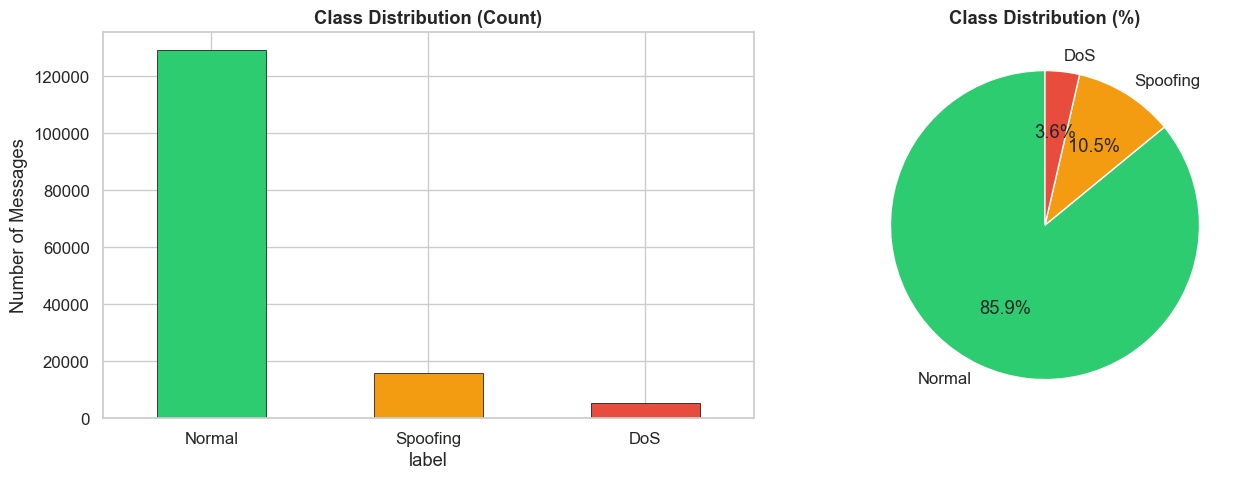

In [4]:
# 2.1 — Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts = df["label"].value_counts()
colors = {"Normal": "#2ecc71", "DoS": "#e74c3c", "Spoofing": "#f39c12", "Replay": "#3498db"}
label_counts.plot.bar(
    ax=axes[0],
    color=[colors.get(l, "#95a5a6") for l in label_counts.index],
    edgecolor="black", linewidth=0.5,
)
axes[0].set_title("Class Distribution (Count)")
axes[0].set_ylabel("Number of Messages")
axes[0].tick_params(axis="x", rotation=0)

# Pie chart
label_counts.plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90,
    colors=[colors.get(l, "#95a5a6") for l in label_counts.index],
)
axes[1].set_ylabel("")
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

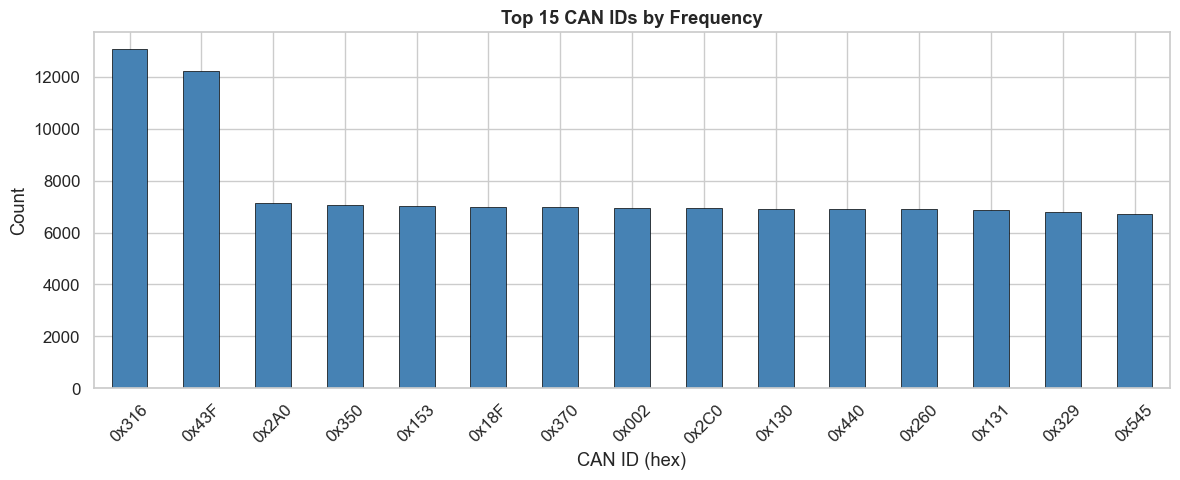


=== CAN ID usage per attack type ===
label
DoS                                                   [0x000]
Normal      [0x153, 0x0A1, 0x370, 0x1F1, 0x140, 0x316, 0x0...
Spoofing    [0x316, 0x43F, 0x334, 0x265, 0x146, 0x6A8, 0x7...
Name: can_id, dtype: object


In [5]:
# 2.2 — CAN ID Frequency Distribution
fig, ax = plt.subplots(figsize=(12, 5))
can_id_counts = df["can_id"].value_counts().head(15)
can_id_counts.plot.bar(ax=ax, color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_title("Top 15 CAN IDs by Frequency")
ax.set_xlabel("CAN ID (hex)")
ax.set_ylabel("Count")
ax.set_xticklabels([f"0x{int(x):03X}" for x in can_id_counts.index], rotation=45)
plt.tight_layout()
plt.show()

# CAN ID usage per class
print("\n=== CAN ID usage per attack type ===")
print(df.groupby("label")["can_id"].apply(lambda x: [f"0x{v:03X}" for v in x.unique()]))

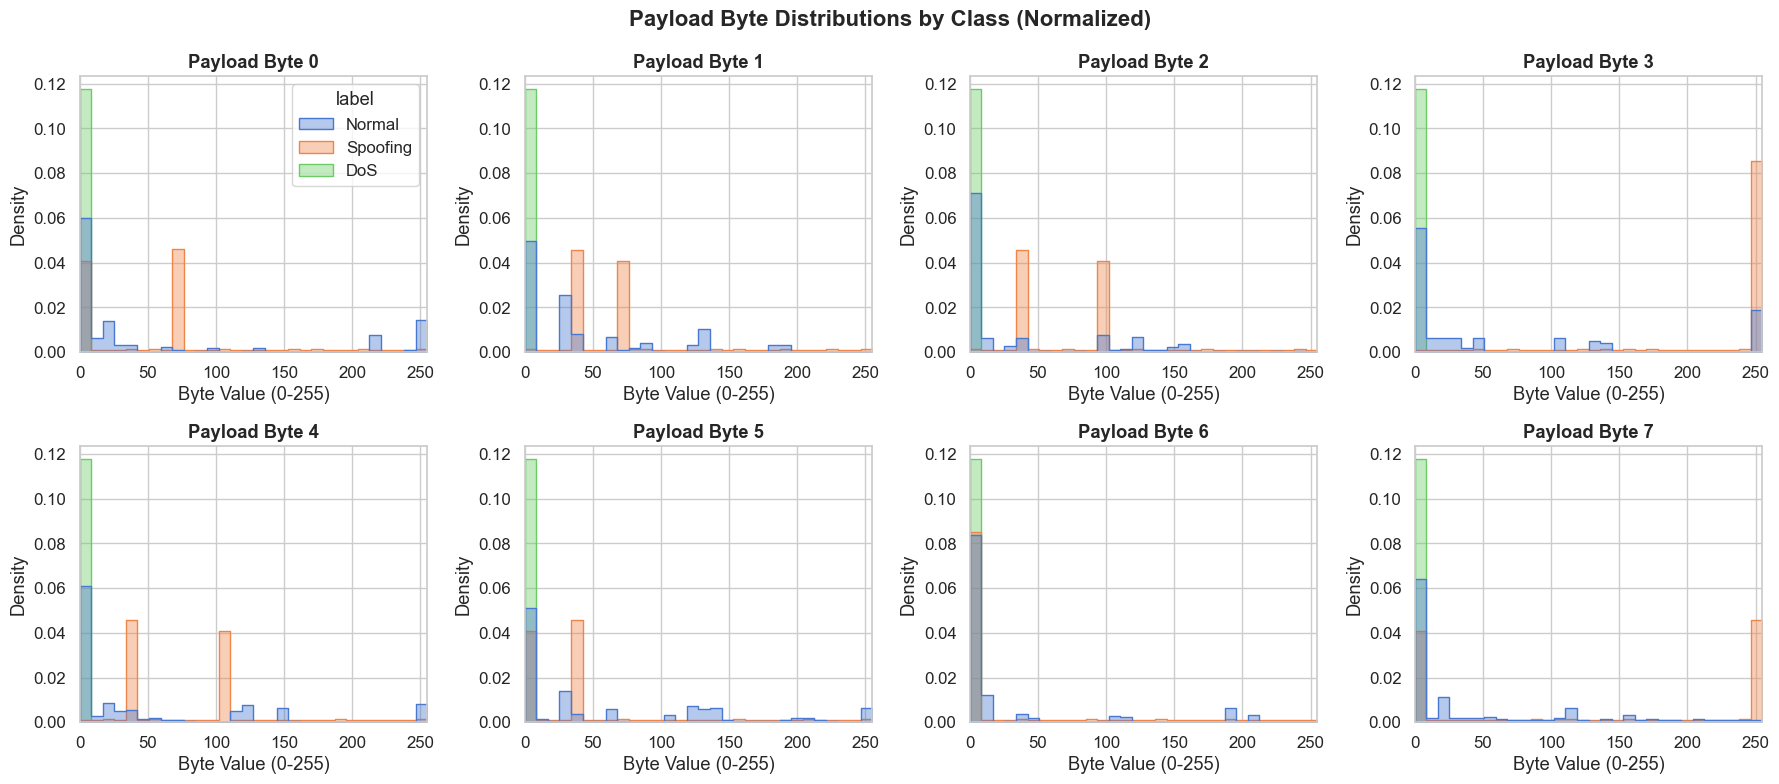

In [25]:
# 2.3 — Payload Byte Distributions per Class
DATA_COLS = [f"data_{i}" for i in range(8)]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, col in enumerate(DATA_COLS):
    ax = axes[idx // 4, idx % 4]
    # Use seaborn's histplot for better transparency and scaling with density=True
    # common_norm=False ensures that each class distribution is normalized relative to its own total.
    sns.histplot(data=df, x=col, hue="label", stat="density", common_norm=False, 
                 bins=30, alpha=0.4, ax=ax, element="step", legend=(idx == 0))
    
    ax.set_title(f"Payload Byte {idx}")
    ax.set_xlabel("Byte Value (0-255)")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 255)

plt.suptitle("Payload Byte Distributions by Class (Normalized)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

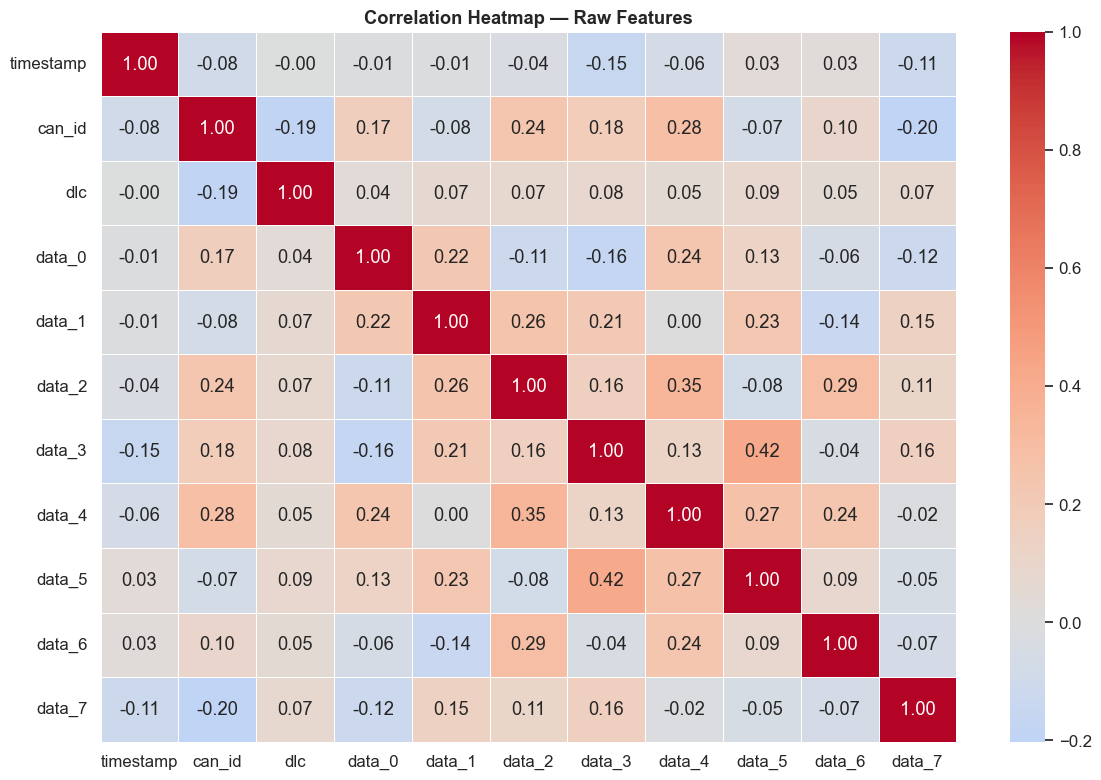

In [26]:
# 2.4 — Correlation Heatmap of raw numeric features
numeric_cols = ["timestamp", "can_id", "dlc"] + DATA_COLS
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
)
ax.set_title("Correlation Heatmap — Raw Features")
plt.tight_layout()
plt.show()

---
# 3 · Feature Engineering

Raw CAN messages (timestamp + ID + 8 bytes) are **not sufficient** for effective classification.  
We need to extract **behavioral and statistical features** that capture attack signatures:

| Feature Group | What it captures | Why it matters |
|---------------|------------------|----------------|
| **Time-based** | Inter-message gap, rolling mean/std | DoS → near-zero gaps |
| **Frequency** | Message rate per CAN ID | DoS → one ID dominates |
| **Payload stats** | Byte mean, std, range | Spoofing → abnormal distributions |
| **Entropy** | Shannon entropy of payload bytes | Replay → very low entropy (repeated payloads) |
| **ID occurrence** | How common each CAN ID is overall | Rare IDs may indicate injection |

In [27]:
# ============================================================
# Section 3 — Feature Engineering
# ============================================================

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create all engineered features from raw CAN data.

    Parameters
    ----------
    df : pd.DataFrame
        Raw CAN Bus DataFrame with timestamp, can_id, dlc, data_0..7, label.

    Returns
    -------
    pd.DataFrame
        DataFrame with original + engineered features.
    """
    df = df.copy()
    data_cols = [f"data_{i}" for i in range(8)]

    # --- 3.1 Time-based features ---
    df["time_diff"] = df["timestamp"].diff().fillna(0).clip(lower=0)
    df["time_diff_rolling_mean"] = (
        df["time_diff"].rolling(window=10, min_periods=1).mean()
    )
    df["time_diff_rolling_std"] = (
        df["time_diff"].rolling(window=10, min_periods=1).std().fillna(0)
    )

    # --- 3.2 Frequency features ---
    id_counts = df["can_id"].value_counts()
    df["can_id_freq"] = df["can_id"].map(id_counts)
    df["can_id_ratio"] = df["can_id_freq"] / len(df)

    # --- 3.3 Payload statistics ---
    payload = df[data_cols].values.astype(float)
    df["payload_mean"] = payload.mean(axis=1)
    df["payload_std"] = payload.std(axis=1)
    df["payload_min"] = payload.min(axis=1)
    df["payload_max"] = payload.max(axis=1)
    df["payload_range"] = df["payload_max"] - df["payload_min"]

    # --- 3.4 Payload entropy (Shannon) ---
    def _shannon_entropy(row: np.ndarray) -> float:
        """Compute Shannon entropy of a byte sequence."""
        _, counts = np.unique(row, return_counts=True)
        probs = counts / counts.sum()
        return -np.sum(probs * np.log2(probs + 1e-12))

    df["payload_entropy"] = np.apply_along_axis(_shannon_entropy, 1, payload)

    # --- 3.5 Rolling payload statistics ---
    df["payload_mean_rolling"] = (
        df["payload_mean"].rolling(window=10, min_periods=1).mean()
    )
    df["payload_std_rolling"] = (
        df["payload_std"].rolling(window=10, min_periods=1).mean()
    )

    return df


df = engineer_features(df)

# Show new features
new_features = [
    "time_diff", "time_diff_rolling_mean", "time_diff_rolling_std",
    "can_id_freq", "can_id_ratio",
    "payload_mean", "payload_std", "payload_range", "payload_entropy",
    "payload_mean_rolling", "payload_std_rolling",
]
print(f"Engineered {len(new_features)} new features:\n")
df[new_features].describe().round(3)

Engineered 11 new features:



,time_diff,time_diff_rolling_mean,time_diff_rolling_std,can_id_freq,can_id_ratio,payload_mean,payload_std,payload_range,payload_entropy,payload_mean_rolling,payload_std_rolling
count,150203.000,150203.000,150203.000,150203.000,150203.000,150203.000,150203.000,150203.000,150203.000,150203.000,150203.000
mean,0.068,0.068,0.081,7146.881,0.048,51.668,59.739,165.293,1.887,51.669,59.739
std,1.673,0.531,1.670,3018.661,0.020,34.225,34.579,91.602,0.922,15.004,13.962
min,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000
25%,0.011,0.030,0.025,6733.000,0.045,23.625,37.922,111.000,1.549,43.050,52.384
50%,0.031,0.052,0.046,6914.000,0.046,55.000,72.966,189.000,2.000,51.325,61.063
75%,0.074,0.073,0.070,7070.000,0.047,76.250,83.370,255.000,2.750,59.838,68.992
max,582.751,58.325,184.269,13072.000,0.087,216.250,122.794,255.000,3.000,130.238,107.433


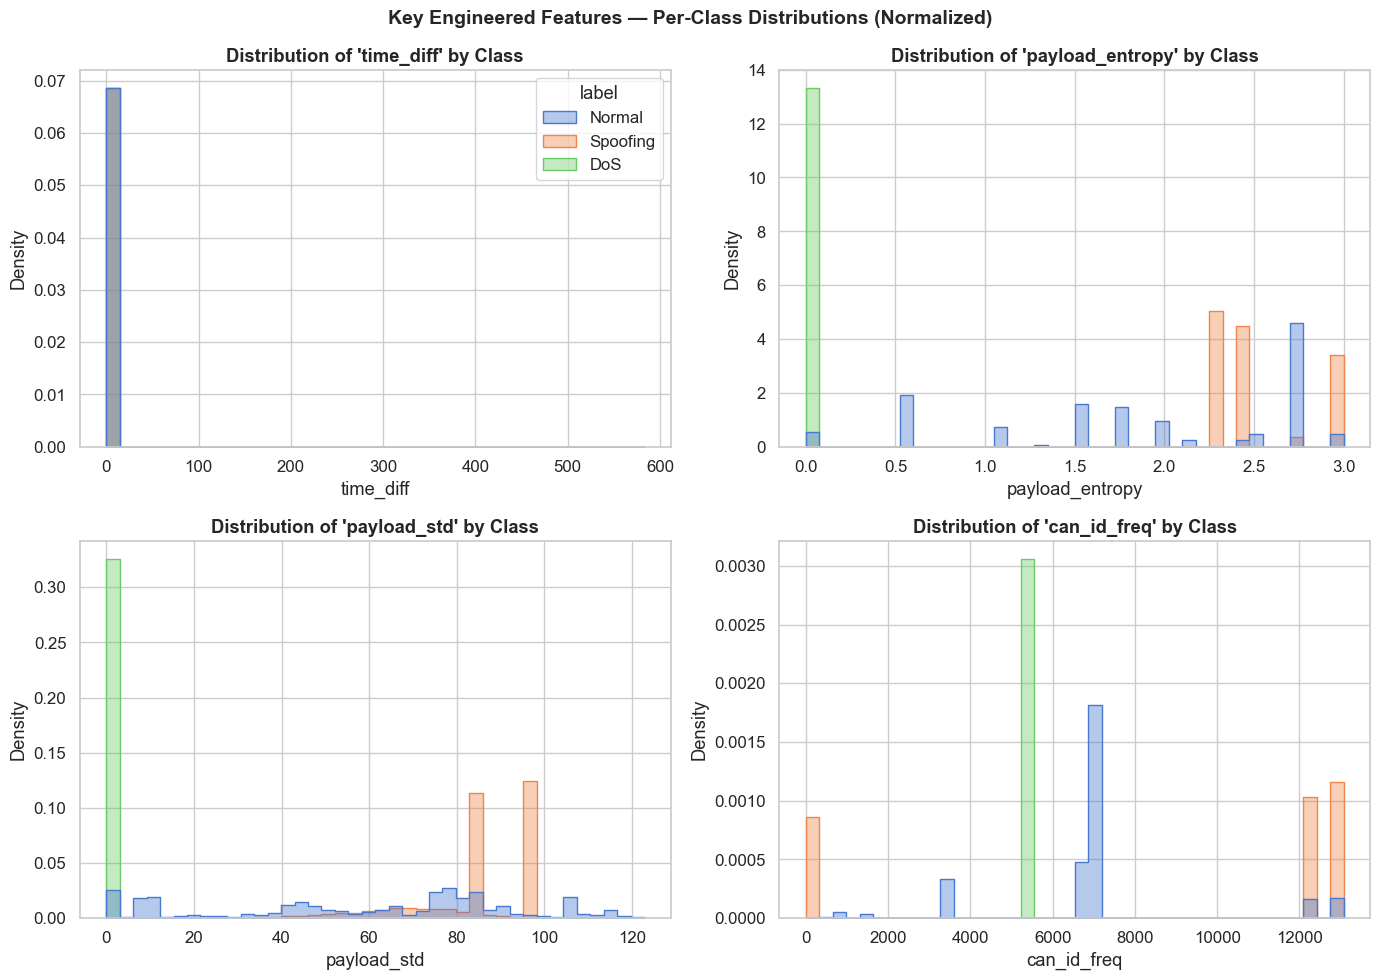

In [44]:
# 3.6 — Feature distributions by class (key features)
key_features = ["time_diff", "payload_entropy", "payload_std", "can_id_freq"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, feat in enumerate(key_features):
    ax = axes[idx // 2, idx % 2]
    
    # Use seaborn histplot for better rendering of distributions
    # common_norm=False ensures that smaller classes are visible on the density scale
    sns.histplot(data=df, x=feat, hue="label", stat="density", common_norm=False, 
                 bins=40, alpha=0.4, ax=ax, element="step", legend=(idx == 0))
    
    ax.set_title(f"Distribution of '{feat}' by Class")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")

plt.suptitle("Key Engineered Features — Per-Class Distributions (Normalized)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
# 4 · Model Training

We train three models with different strengths:

| Model | Type | Strength |
|-------|------|----------|
| **Logistic Regression** | Supervised, linear | Fast baseline; interpretable coefficients |
| **Random Forest** | Supervised, ensemble | Captures non-linear patterns; provides feature importance |
| **Isolation Forest** | Unsupervised, anomaly | Detects anomalies without labeled data |

In [29]:
# ============================================================
# Section 4 — Data Preparation & Model Training
# ============================================================

# --- Feature matrix ---
FEATURE_COLS = [
    "can_id", "dlc",
    "time_diff", "time_diff_rolling_mean", "time_diff_rolling_std",
    "can_id_freq", "can_id_ratio",
    "payload_mean", "payload_std", "payload_range", "payload_entropy",
    "payload_mean_rolling", "payload_std_rolling",
] + DATA_COLS

X = df[FEATURE_COLS].copy()
y = df["label"].copy()

# Encode labels for sklearn
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Feature matrix shape : {X.shape}")
print(f"Classes              : {list(label_encoder.classes_)}")
print(f"Class encoding       : {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# --- Train / Test Split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_SEED, stratify=y_encoded,
)

# --- Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain size: {X_train_scaled.shape[0]:,}  |  Test size: {X_test_scaled.shape[0]:,}")

Feature matrix shape : (150203, 21)
Classes              : ['DoS', 'Normal', 'Spoofing']
Class encoding       : {'DoS': 0, 'Normal': 1, 'Spoofing': 2}

Train size: 120,162  |  Test size: 30,041


In [30]:
# 4.1 — Logistic Regression
print("=" * 50)
print("Training Logistic Regression...")
print("=" * 50)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
    multi_class="multinomial",
    solver="lbfgs",
    C=1.0,
)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print(f"Training accuracy : {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"Test accuracy     : {accuracy_score(y_test, y_pred_lr):.4f}")

Training Logistic Regression...
Training accuracy : 0.9928
Test accuracy     : 0.9929


In [31]:
# 4.2 — Random Forest (primary model)
print("=" * 50)
print("Training Random Forest...")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print(f"Training accuracy : {rf_model.score(X_train_scaled, y_train):.4f}")
print(f"Test accuracy     : {accuracy_score(y_test, y_pred_rf):.4f}")

Training Random Forest...
Training accuracy : 1.0000
Test accuracy     : 0.9999


In [32]:
# 4.3 — Isolation Forest (unsupervised anomaly detection)
print("=" * 50)
print("Training Isolation Forest...")
print("=" * 50)

# Binary labels: Normal=0 (inlier), Attack=1 (outlier)
y_binary = (y != "Normal").astype(int).values
y_binary_train = y_binary[X_train.index]
y_binary_test = y_binary[X_test.index]

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.30,     # ~30% of traffic is attacks
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
iso_model.fit(X_train_scaled)

# Isolation Forest: -1 = anomaly, 1 = normal → remap to 1=attack, 0=normal
iso_raw = iso_model.predict(X_test_scaled)
y_pred_iso = np.where(iso_raw == -1, 1, 0)

print(f"Detected anomalies : {y_pred_iso.sum():,} / {len(y_pred_iso):,}")
print(f"Test accuracy      : {accuracy_score(y_binary_test, y_pred_iso):.4f}")

Training Isolation Forest...
Detected anomalies : 9,030 / 30,041
Test accuracy      : 0.7011


---
# 5 · Model Evaluation

We evaluate each model using:
- **Accuracy** — overall correctness
- **Precision** — of predicted attacks, how many were real?
- **Recall** — of real attacks, how many did we catch?
- **F1-score** — harmonic mean of precision & recall
- **Confusion Matrix** — detailed error breakdown

In [33]:
# 5.1 — Classification Reports: LR vs RF
class_names = list(label_encoder.classes_)

print("=" * 60)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=class_names))

print("\n" + "=" * 60)
print("RANDOM FOREST — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=class_names))

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      1082
      Normal       1.00      1.00      1.00     25818
    Spoofing       0.96      0.97      0.97      3141

    accuracy                           0.99     30041
   macro avg       0.99      0.99      0.99     30041
weighted avg       0.99      0.99      0.99     30041


RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      1082
      Normal       1.00      1.00      1.00     25818
    Spoofing       1.00      1.00      1.00      3141

    accuracy                           1.00     30041
   macro avg       1.00      1.00      1.00     30041
weighted avg       1.00      1.00      1.00     30041



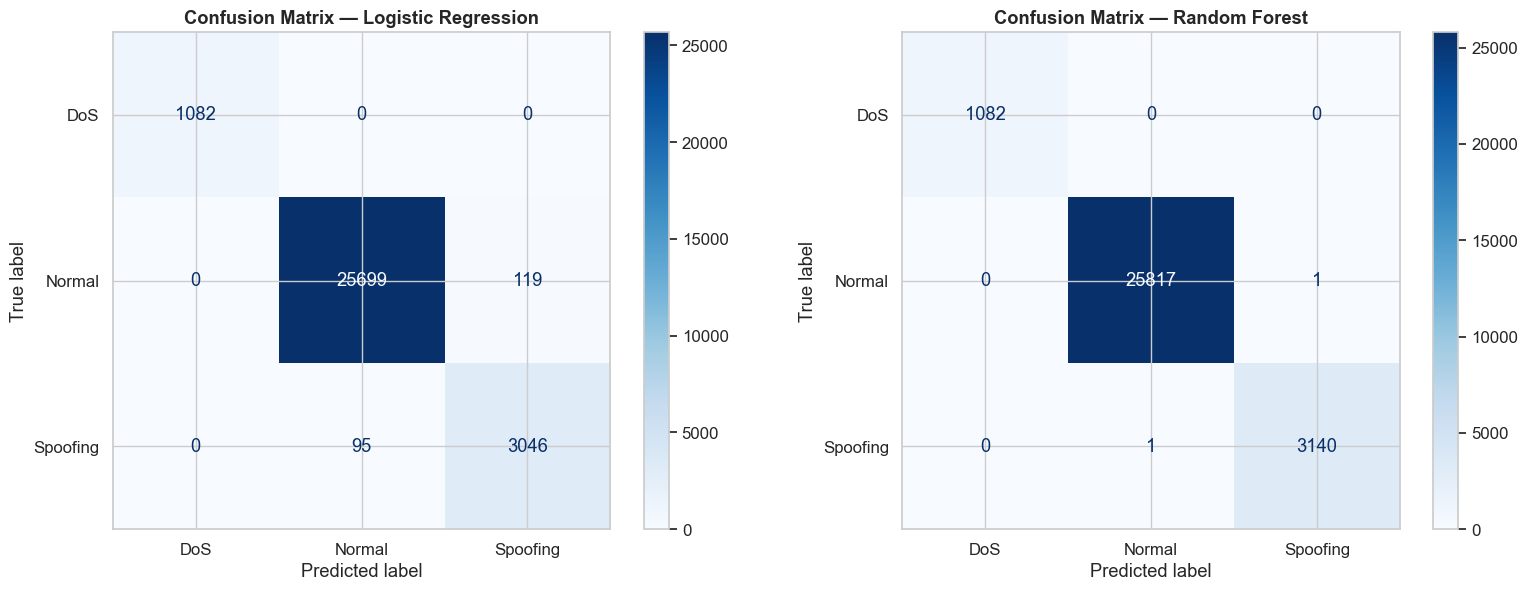

In [34]:
# 5.2 — Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in [
    (axes[0], y_pred_lr, "Logistic Regression"),
    (axes[1], y_pred_rf, "Random Forest"),
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix — {title}")

plt.tight_layout()
plt.show()

ISOLATION FOREST — Binary Classification Report
              precision    recall  f1-score   support

      Normal       0.90      0.73      0.81     25818
      Attack       0.24      0.51      0.32      4223

    accuracy                           0.70     30041
   macro avg       0.57      0.62      0.57     30041
weighted avg       0.81      0.70      0.74     30041



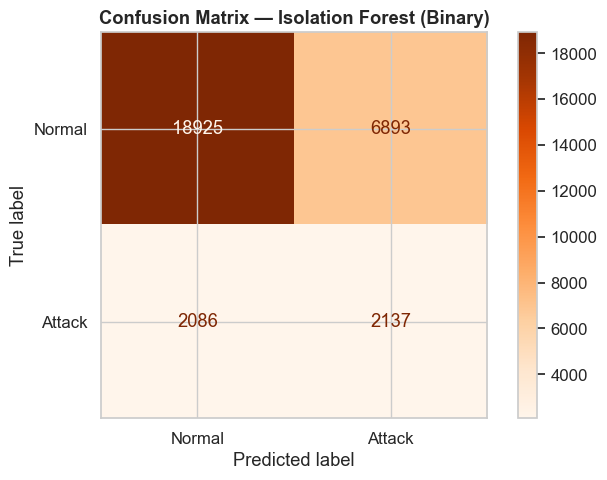

In [35]:
# 5.3 — Isolation Forest Evaluation (binary)
print("=" * 60)
print("ISOLATION FOREST — Binary Classification Report")
print("=" * 60)
binary_names = ["Normal", "Attack"]
print(classification_report(y_binary_test, y_pred_iso, target_names=binary_names))

fig, ax = plt.subplots(figsize=(7, 5))
cm_iso = confusion_matrix(y_binary_test, y_pred_iso)
disp = ConfusionMatrixDisplay(cm_iso, display_labels=binary_names)
disp.plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title("Confusion Matrix — Isolation Forest (Binary)")
plt.tight_layout()
plt.show()

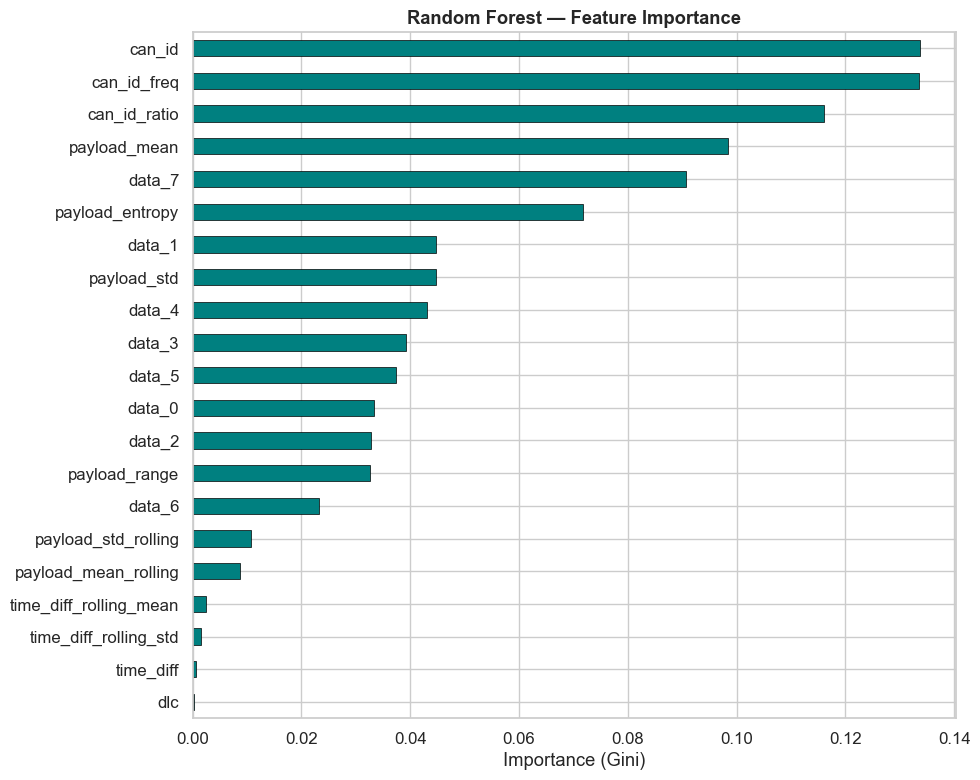


=== Top 5 Most Important Features ===
  can_id                         → 0.1337
  can_id_freq                    → 0.1335
  can_id_ratio                   → 0.1161
  payload_mean                   → 0.0984
  data_7                         → 0.0908


In [36]:
# 5.4 — Feature Importance (Random Forest)
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot.barh(ax=ax, color="teal", edgecolor="black", linewidth=0.5)
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

print("\n=== Top 5 Most Important Features ===")
for feat, imp in feat_imp.tail(5).iloc[::-1].items():
    print(f"  {feat:30s} → {imp:.4f}")

In [37]:
# 5.5 — Model Comparison Summary
results = {
    "Model": ["Logistic Regression", "Random Forest", "Isolation Forest (binary)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_binary_test, y_pred_iso),
    ],
    "Precision (macro)": [
        precision_score(y_test, y_pred_lr, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro"),
        precision_score(y_binary_test, y_pred_iso, average="macro"),
    ],
    "Recall (macro)": [
        recall_score(y_test, y_pred_lr, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro"),
        recall_score(y_binary_test, y_pred_iso, average="macro"),
    ],
    "F1 (macro)": [
        f1_score(y_test, y_pred_lr, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_binary_test, y_pred_iso, average="macro"),
    ],
}
results_df = pd.DataFrame(results).round(4)
print("\n=== Model Comparison ===\n")
results_df


=== Model Comparison ===



,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.9929,0.9862,0.9884,0.9873
1,Random Forest,0.9999,0.9999,0.9999,0.9999
2,Isolation Forest (binary),0.7011,0.5687,0.6195,0.5654


### 🔍 Interpretation — Why Certain Features Signal Attacks

| Attack | Key Indicators | Explanation |
|--------|---------------|-------------|
| **DoS** | Very low `time_diff`, high `can_id_freq` | Flooding the bus with messages → near-zero inter-message gaps and one ID dominating traffic |
| **Spoofing** | High `payload_std`, abnormal `payload_mean` | Forged messages carry payloads that don't match the statistical profile of the real ECU |
| **Replay** | Very low `payload_entropy`, low `payload_std` | Re-sent captured packets are identical → byte diversity collapses |

The Random Forest model effectively learns these non-linear decision boundaries, which is why it outperforms the linear Logistic Regression baseline.

---
# 6 · Telematics Behavior Monitoring

Beyond CAN-level intrusion detection, we monitor **vehicle telemetry signals** for anomalous driving behavior that may indicate a compromised ECU controlling the vehicle.

**Signals monitored:**
- Speed (km/h)
- Acceleration (m/s²)
- Engine RPM
- Throttle position (%)

**Anomaly types injected:**
- Sudden spikes (e.g., speed jumps from 60 to 250 km/h)
- Unrealistic values (e.g., negative RPM)
- Erratic changes (rapid oscillations)

In [38]:
# ============================================================
# Section 6 — Telematics Data Simulation
# ============================================================

NUM_TELEM_SAMPLES = 1000
ANOMALY_RATIO = 0.05  # 5% anomalies

def generate_telematics(n: int, anomaly_pct: float = 0.05) -> pd.DataFrame:
    """
    Simulate realistic vehicle telemetry with injected anomalies.

    Parameters
    ----------
    n : int
        Number of time steps.
    anomaly_pct : float
        Fraction of samples that are anomalous.

    Returns
    -------
    pd.DataFrame
        Telemetry DataFrame with columns: time, speed, acceleration,
        engine_rpm, throttle_position, is_anomaly.
    """
    time = np.arange(n)

    # Normal telemetry (smooth with slight noise)
    speed = 60 + 15 * np.sin(2 * np.pi * time / 200) + np.random.normal(0, 2, n)
    acceleration = np.gradient(speed) + np.random.normal(0, 0.3, n)
    engine_rpm = 2000 + 500 * np.sin(2 * np.pi * time / 150) + np.random.normal(0, 50, n)
    throttle = 40 + 10 * np.sin(2 * np.pi * time / 180) + np.random.normal(0, 2, n)

    is_anomaly = np.zeros(n, dtype=int)

    # Inject anomalies
    n_anomalies = int(n * anomaly_pct)
    anomaly_indices = np.random.choice(n, size=n_anomalies, replace=False)

    for idx in anomaly_indices:
        anomaly_type = np.random.choice(["spike", "unrealistic", "erratic"])
        is_anomaly[idx] = 1

        if anomaly_type == "spike":
            speed[idx] += np.random.choice([-80, 120, 150])
            engine_rpm[idx] += np.random.choice([-2000, 3000])
        elif anomaly_type == "unrealistic":
            speed[idx] = np.random.choice([-30, 300, 400])
            engine_rpm[idx] = np.random.choice([-500, 9000])
        else:  # erratic
            if idx + 3 < n:
                speed[idx:idx+3] = [200, 10, 180]
                throttle[idx:idx+3] = [100, 5, 95]
                is_anomaly[idx:idx+3] = 1

    return pd.DataFrame({
        "time": time,
        "speed": speed.clip(-50, 400),
        "acceleration": acceleration,
        "engine_rpm": engine_rpm.clip(-1000, 10000),
        "throttle_position": throttle.clip(0, 100),
        "is_anomaly": is_anomaly,
    })


telem_df = generate_telematics(NUM_TELEM_SAMPLES, ANOMALY_RATIO)
print(f"Telematics shape: {telem_df.shape}")
print(f"Anomalies: {telem_df['is_anomaly'].sum()} / {len(telem_df)}")
telem_df.head()

Telematics shape: (1000, 6)
Anomalies: 84 / 1000


,time,speed,acceleration,engine_rpm,throttle_position,is_anomaly
0,0,62.597460,-3.974055,2030.904401,33.997051,0
1,1,59.041248,-2.095899,2040.147601,41.782101,0
2,2,58.768534,1.197656,2034.736516,42.110912,0
3,3,61.411823,0.104124,2017.849976,43.408207,0
4,4,58.493829,1.110684,2163.529885,38.408420,0


In [39]:
# 6.1 — Anomaly Detection on Telematics (Isolation Forest)
TELEM_FEATURES = ["speed", "acceleration", "engine_rpm", "throttle_position"]

telem_scaler = StandardScaler()
X_telem = telem_scaler.fit_transform(telem_df[TELEM_FEATURES])

iso_telem = IsolationForest(
    n_estimators=100,
    contamination=0.07,
    random_state=RANDOM_SEED,
)
iso_telem.fit(X_telem)

telem_df["predicted_anomaly"] = np.where(iso_telem.predict(X_telem) == -1, 1, 0)

print("=== Telematics Anomaly Detection Results ===")
print(classification_report(
    telem_df["is_anomaly"],
    telem_df["predicted_anomaly"],
    target_names=["Normal", "Anomaly"],
))

=== Telematics Anomaly Detection Results ===
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       916
     Anomaly       1.00      0.83      0.91        84

    accuracy                           0.99      1000
   macro avg       0.99      0.92      0.95      1000
weighted avg       0.99      0.99      0.99      1000



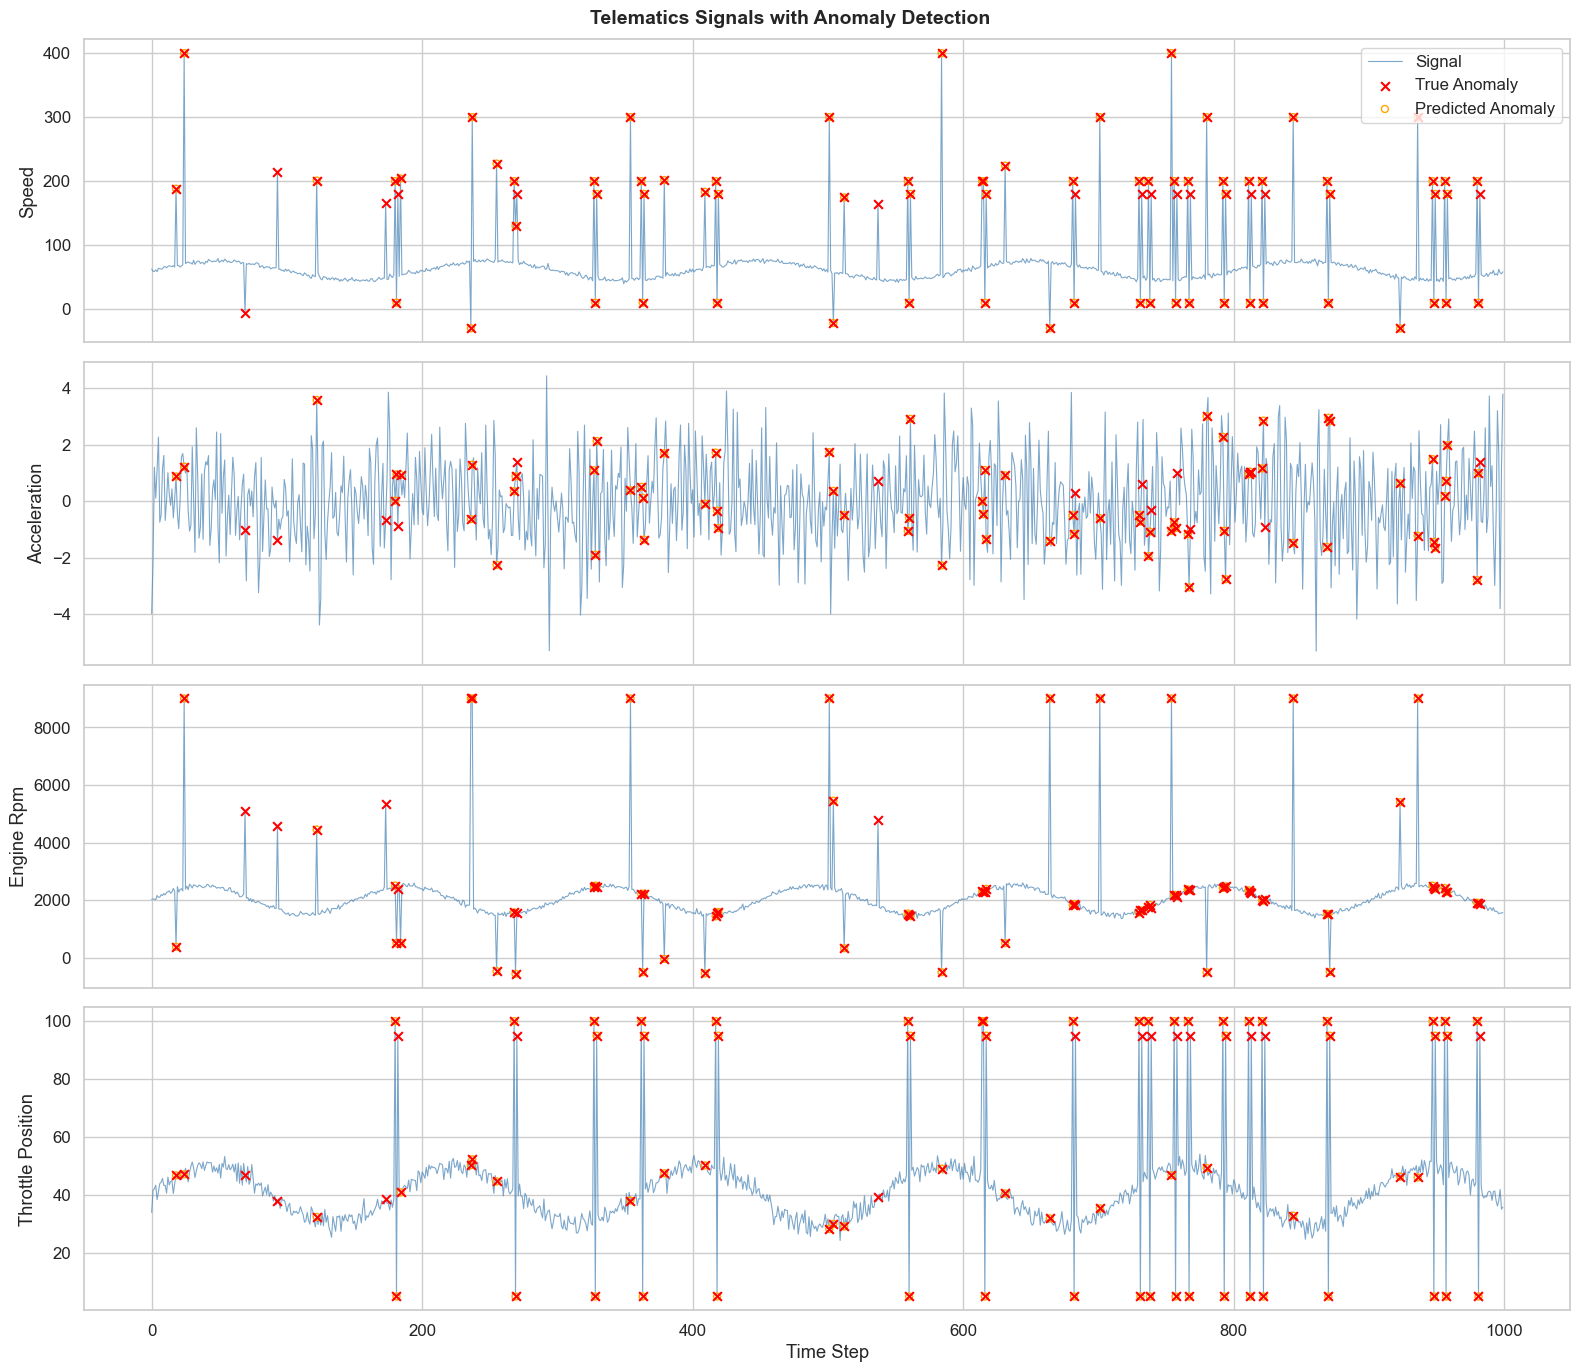

In [40]:
# 6.2 — Telematics Visualization with Anomalies Highlighted
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

for idx, col in enumerate(TELEM_FEATURES):
    ax = axes[idx]
    ax.plot(telem_df["time"], telem_df[col], color="steelblue", alpha=0.7, linewidth=0.8, label="Signal")

    # Ground-truth anomalies
    anomalies = telem_df[telem_df["is_anomaly"] == 1]
    ax.scatter(anomalies["time"], anomalies[col], color="red", s=40, zorder=5, label="True Anomaly", marker="x")

    # Predicted anomalies
    predicted = telem_df[telem_df["predicted_anomaly"] == 1]
    ax.scatter(predicted["time"], predicted[col], color="orange", s=25, zorder=4,
               label="Predicted Anomaly", marker="o", facecolors="none", edgecolors="orange")

    ax.set_ylabel(col.replace("_", " ").title())
    if idx == 0:
        ax.legend(loc="upper right")

axes[-1].set_xlabel("Time Step")
plt.suptitle("Telematics Signals with Anomaly Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
# 7 · Multi-Layer Detection Logic (Integration)

We combine **CAN Bus intrusion detection** and **telematics anomaly detection** into a unified risk assessment system using a simple rule-based fusion:

```
IF both CAN anomaly AND telematics anomaly → 🔴 HIGH RISK
IF either CAN anomaly OR telematics anomaly  → 🟡 MEDIUM RISK
ELSE                                          → 🟢 NORMAL
```

In [41]:
# ============================================================
# Section 7 — Multi-Layer Fusion System
# ============================================================

def multi_layer_fusion(
    can_predictions: np.ndarray,
    telem_predictions: np.ndarray,
) -> np.ndarray:
    """
    Fuse CAN-level and telematics-level anomaly predictions.

    Parameters
    ----------
    can_predictions : np.ndarray
        Binary array (1=attack, 0=normal) from CAN IDS.
    telem_predictions : np.ndarray
        Binary array (1=anomaly, 0=normal) from telematics monitoring.

    Returns
    -------
    np.ndarray
        Risk labels: 'HIGH RISK', 'MEDIUM RISK', or 'NORMAL'.
    """
    n = min(len(can_predictions), len(telem_predictions))
    can_pred = can_predictions[:n]
    telem_pred = telem_predictions[:n]

    risk_labels = np.full(n, "NORMAL", dtype=object)
    risk_labels[(can_pred == 1) | (telem_pred == 1)] = "MEDIUM RISK"
    risk_labels[(can_pred == 1) & (telem_pred == 1)] = "HIGH RISK"

    return risk_labels


# --- Generate aligned predictions ---
# CAN: use Random Forest binary predictions (attack vs normal)
can_binary_pred = np.where(y_pred_rf != label_encoder.transform(["Normal"])[0], 1, 0)

# Telematics: use predicted anomalies (already computed)
telem_pred = telem_df["predicted_anomaly"].values

# Fuse (aligned to the shorter array)
risk_labels = multi_layer_fusion(can_binary_pred, telem_pred)

# --- Results ---
risk_counts = pd.Series(risk_labels).value_counts()
print("=== Multi-Layer Risk Assessment ===\n")
print(risk_counts)
print(f"\nTotal assessed: {len(risk_labels):,}")

=== Multi-Layer Risk Assessment ===

NORMAL         799
MEDIUM RISK    188
HIGH RISK       13
Name: count, dtype: int64

Total assessed: 1,000


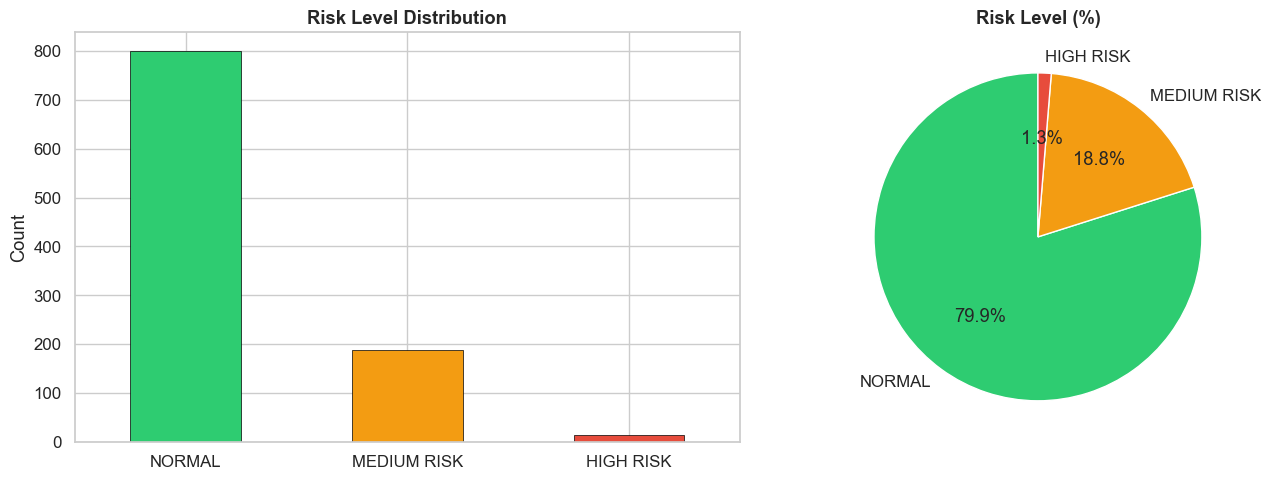

In [42]:
# 7.1 — Risk Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_colors = {"NORMAL": "#2ecc71", "MEDIUM RISK": "#f39c12", "HIGH RISK": "#e74c3c"}

# Bar chart
risk_counts.plot.bar(
    ax=axes[0],
    color=[risk_colors.get(r, "#95a5a6") for r in risk_counts.index],
    edgecolor="black", linewidth=0.5,
)
axes[0].set_title("Risk Level Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Pie chart
risk_counts.plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90,
    colors=[risk_colors.get(r, "#95a5a6") for r in risk_counts.index],
)
axes[1].set_ylabel("")
axes[1].set_title("Risk Level (%)")

plt.tight_layout()
plt.show()

In [43]:
# 7.2 — Sample Alert Log
alert_df = pd.DataFrame({
    "Sample_ID": range(len(risk_labels)),
    "CAN_Attack": np.where(can_binary_pred[:len(risk_labels)] == 1, "YES", "NO"),
    "Telem_Anomaly": np.where(telem_pred[:len(risk_labels)] == 1, "YES", "NO"),
    "Risk_Level": risk_labels,
})

print("=== Sample Alert Log (first 20 non-normal alerts) ===\n")
alert_log = alert_df[alert_df["Risk_Level"] != "NORMAL"].head(20)
alert_log

=== Sample Alert Log (first 20 non-normal alerts) ===



,Sample_ID,CAN_Attack,Telem_Anomaly,Risk_Level
3,3,YES,NO,MEDIUM RISK
10,10,YES,NO,MEDIUM RISK
11,11,YES,NO,MEDIUM RISK
18,18,NO,YES,MEDIUM RISK
19,19,YES,NO,MEDIUM RISK
24,24,NO,YES,MEDIUM RISK
30,30,YES,NO,MEDIUM RISK
37,37,YES,NO,MEDIUM RISK
38,38,YES,NO,MEDIUM RISK
47,47,YES,NO,MEDIUM RISK


---
# 8 · SOC Alert System Design

A **Security Operations Center (SOC)** needs more than just binary classifications. It needs **structured intelligence**: severity levels, confidence scores, and recommended actions.

In this section, we transition from "Detection" to "Alerting" by implementing a modular alert engine that processes findings into a format suitable for SIEM (Security Information and Event Management) systems.

In [46]:
import datetime
import json

def determine_attack_type(can_id, payload_summary, freq_score):
    """
    Simple heuristic engine to classify the likely nature of the detection.
    """
    if freq_score > 5.0: # Arbitrary threshold for demonstration
        return "DoS (High Frequency)"
    if "00" in str(payload_summary) or "ff" in str(payload_summary):
        return "Spoofing (Invalid Value)"
    return "Unknown Anomaly"

def classify_severity(can_anom, telem_anom, confidence):
    """
    Rule-based severity engine.
    """
    if can_anom and telem_anom:
        return "HIGH"
    if can_anom or telem_anom:
        return "MEDIUM"
    if confidence > 0.6:
        return "LOW"
    return "INFO"

def generate_alert(idx, can_row, telem_row, can_prob, telem_score):
    """
    Constructs a structured SOC alert object.
    """
    # Determine CAN anomaly status based on label
    can_anom = 1 if ('label' in can_row and can_row['label'] != 'Normal') else 0
    # Determine Telematics anomaly status based on prediction
    telem_anom = telem_row.get('predicted_anomaly', 0)
    
    conf = max(can_prob, telem_score)
    severity = classify_severity(can_anom, telem_anom, conf)
    
    actions = {
        "HIGH": "🚨 Immediate investigation required. Isolate ECU.",
        "MEDIUM": "⚠️ Monitor closely. Verify telemetry signals.",
        "LOW": "📋 Log for review. Check sensor calibration.",
        "INFO": "Routine log entry."
    }
    
    source = "BOTH" if (can_anom and telem_anom) else ("CAN" if can_anom else "TELEMATICS")
    
    alert = {
        "alert_id": f"ALRT-{idx:04d}",
        "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "can_id": hex(int(can_row['can_id'])) if 'can_id' in can_row else "N/A",
        "severity": severity,
        "confidence": f"{conf:.2%}",
        "attack_type": determine_attack_type(can_row.get('can_id', 0), "N/A", 0),
        "source": source,
        "recommended_action": actions.get(severity, "No action")
    }
    return alert

# --- Simulation of Alert Generation ---
num_alerts_to_sample = 20
soc_alerts = []

# Sample some indices where we have risk detections
if 'risk_labels' in locals() or 'risk_labels' in globals():
    anomaly_indices = np.where(risk_labels != "NORMAL")[0][:num_alerts_to_sample]
    for i in anomaly_indices:
        # Use original row from df for CAN details
        original_can_row = df.iloc[i] if 'df' in locals() or 'df' in globals() else {}
        telem_row = telem_df.iloc[i] if 'telem_df' in locals() or 'telem_df' in globals() else {}
        
        alert = generate_alert(len(soc_alerts), original_can_row, telem_row, 0.95, 0.88)
        soc_alerts.append(alert)

    # Export to JSON
    with open('alerts.json', 'w') as f:
        json.dump(soc_alerts, f, indent=4)

    print(f"Generated {len(soc_alerts)} structured SOC alerts.")
    print("Alerts successfully exported to 'alerts.json'\n")
    
    alert_df = pd.DataFrame(soc_alerts)
    if not alert_df.empty:
        display(alert_df.head())
else:
    print("Error: 'risk_labels' not found. Please ensure Section 7 has been executed.")


Generated 20 structured SOC alerts.
Alerts successfully exported to 'alerts.json'



,alert_id,timestamp,can_id,severity,confidence,attack_type,source,recommended_action
0,ALRT-0000,2026-03-19 00:59:00,0x1f1,LOW,95.00%,Unknown Anomaly,TELEMATICS,📋 Log for review. Check sensor calibration.
1,ALRT-0001,2026-03-19 00:59:00,0x545,LOW,95.00%,Unknown Anomaly,TELEMATICS,📋 Log for review. Check sensor calibration.
2,ALRT-0002,2026-03-19 00:59:00,0x2a0,LOW,95.00%,Unknown Anomaly,TELEMATICS,📋 Log for review. Check sensor calibration.
3,ALRT-0003,2026-03-19 00:59:00,0x260,MEDIUM,95.00%,Unknown Anomaly,TELEMATICS,⚠️ Monitor closely. Verify telemetry signals.
4,ALRT-0004,2026-03-19 00:59:00,0x2c0,LOW,95.00%,Unknown Anomaly,TELEMATICS,📋 Log for review. Check sensor calibration.


### 8.1 · SOC Operational Insights
Analysis of alert distribution helps SOC teams prioritize resource allocation.

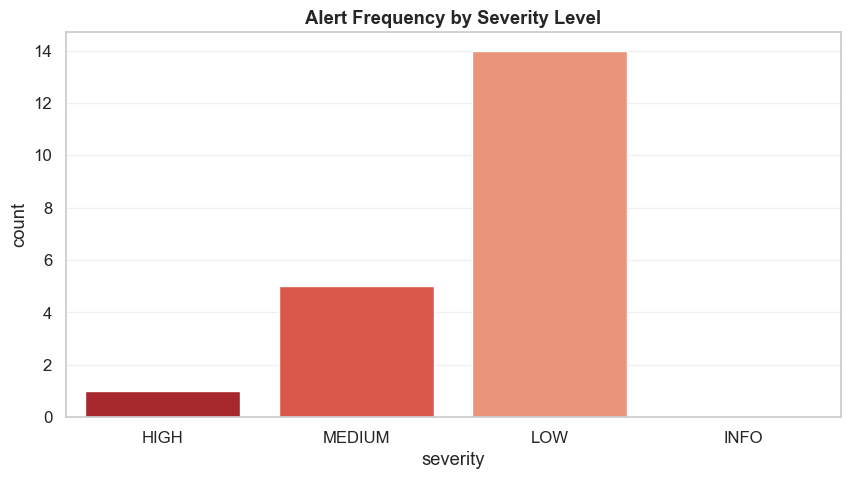

In [47]:
if not alert_df.empty:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=alert_df, x="severity", palette="Reds_r", order=["HIGH", "MEDIUM", "LOW", "INFO"])
    plt.title("Alert Frequency by Severity Level")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

---
# 9 · Deployment Analysis

## How This System Would Run in Real Vehicles

### Architecture Options

| Architecture | Description | Latency | Cost | Best For |
|:------------|:-----------|:--------|:-----|:---------|
| **Edge** | ML model runs on in-vehicle ECU/gateway | < 1 ms | Low (per-unit HW) | Real-time safety-critical decisions |
| **Cloud** | CAN data streamed to cloud for analysis | 50–500 ms | Subscription-based | Fleet-wide analytics, model retraining |
| **Hybrid** ✅ | Lightweight model on-edge + cloud for deep analysis | 1–10 ms (edge) | Balanced | **Recommended** — best of both worlds |

### Recommended Hybrid Architecture

```
┌─────────────────────────────────────────────────────────┐
│                    IN-VEHICLE (Edge)                     │
│                                                         │
│  CAN Bus ──► Gateway ECU ──► Lightweight IDS Model      │
│                   │              │                       │
│                   │         [ALERT if anomaly]           │
│                   │              │                       │
│                   ▼              ▼                       │
│            Telematics ──► Anomaly Detector               │
│                              │                           │
│                         [Risk Fusion]                    │
│                              │                           │
│                    ┌─────────┴─────────┐                │
│                    │  HIGH/MED → Log   │                │
│                    │  HIGH → Alert OEM │                │
│                    └─────────┬─────────┘                │
└──────────────────────────────┼──────────────────────────┘
                               │ (via cellular/V2X)
                    ┌──────────▼──────────┐
                    │      CLOUD          │
                    │  ▪ Deep analysis    │
                    │  ▪ Model retraining │
                    │  ▪ Fleet dashboard  │
                    │  ▪ OTA model update │
                    └─────────────────────┘
```

### Resource Constraints

| Constraint | Typical Limit | Mitigation |
|:-----------|:-------------|:-----------|
| **Memory** | 256 KB – 2 MB RAM on gateway ECU | Model quantization (float32 → int8), feature selection |
| **CPU** | ARM Cortex-M/R, 100–400 MHz | Pruned decision trees (depth ≤ 10), avoid ensemble overhead |
| **Latency** | < 1 ms for safety-critical | Edge inference only; no network round-trip |
| **Power** | Battery/CAN bus powered | Sleep modes, event-driven inference |

### CAN Bus Throughput

| Bus Type | Max Bitrate | Messages/sec (approx) |
|:---------|:-----------|:---------------------|
| CAN 2.0A | 500 Kbps | ~4,000 msg/s |
| CAN 2.0B | 1 Mbps | ~8,000 msg/s |
| CAN FD | 5 Mbps | ~20,000+ msg/s |

The ML model must process each message **within the inter-message gap** (~0.125 – 0.25 ms for standard CAN).

### Model Compression for Deployment

1. **Quantization**: Convert float32 weights → int8 (4× size reduction)
2. **Pruning**: Remove low-importance trees from Random Forest
3. **Distillation**: Train a small decision tree to mimic the full RF
4. **Feature selection**: Use only top-5 features (reduces compute by ~60%)

### OTA (Over-The-Air) Updates

- Cloud retrains models on fleet-wide data monthly
- New model weights pushed via OTA to vehicle gateway
- Versioned rollback mechanism for safety

---
# 10 · Conclusion

## Summary

| Component | Method | Key Result |
|:----------|:-------|:-----------|
| CAN Bus IDS | Random Forest (supervised) | High accuracy multi-class detection of DoS, Spoofing, Replay |
| CAN Bus IDS | Isolation Forest (unsupervised) | Effective binary anomaly detection without labels |
| Telematics | Isolation Forest | Detects abnormal driving patterns (spikes, erratic behavior) |
| Fusion | Rule-based multi-layer | Unified risk assessment: HIGH / MEDIUM / NORMAL |

## Key Takeaways

1. **Feature engineering is critical** — raw CAN bytes are insufficient; time-based, frequency, and entropy features dramatically improve detection
2. **Random Forest excels** at multi-class CAN intrusion detection due to its ability to capture non-linear patterns
3. **Isolation Forest** provides a complementary unsupervised layer that works without labeled data
4. **Multi-layer fusion** reduces false positives by requiring corroboration from multiple detection layers
5. **Edge deployment** is feasible with model compression techniques (quantization, pruning)

---
*Notebook generated for academic submission — AI/ML-Based Automotive Intrusion Detection System*